In [16]:
import pandas as pd
import numpy as np 
from matplotlib import pyplot as plt

df_basin = pd.read_csv("../../CSV/IAMC/Emi_CO2_basin.csv")
df_region = pd.read_csv("../../CSV/IAMC/Emi_CO2_region.csv")
df_basin["valueb"]=df_basin["value"]
df_region["valuer"]=df_region["value"]

In [17]:
region_name_map = {
    "USA": "USA",
    "XE25": "EU",
    "XER": "Rest of EU",
    "TUR": "Turkey",
    "XOC": "Oceania",
    "CHN": "China",
    "IND": "India",
    "JPN": "Japan",
    "XSE": "Rest of SE Asia",
    "XSA": "Rest of Asia",
    "CAN": "Canada",
    "BRA": "Brazil",
    "XLM": "Latin America",
    "CIS": "Former USSR",
    "XME": "Middle East",
    "XNF": "North Africa",
    "XAF": "Sub-Sahara Africa",
}

In [18]:
df_b_raw= df_basin[["region","year","valueb"]]
df_r_raw= df_region[["region","year","valuer"]]
df_filtered_r = df_r_raw[df_r_raw["region"].isin(region_name_map.keys())]
df_filtered_b = df_b_raw[df_b_raw["region"].isin(region_name_map.keys())]
df_filtered_r["region"] = df_filtered_r["region"].map(region_name_map).copy()
df_filtered_b["region"] = df_filtered_b["region"].map(region_name_map).copy()
df_merged = pd.merge(
    df_filtered_r,df_filtered_b,on=["year","region"],how="inner"
)


C:\Users\ZSR\AppData\Local\Temp\ipykernel_1848\4168377222.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_r["region"] = df_filtered_r["region"].map(region_name_map).copy()
C:\Users\ZSR\AppData\Local\Temp\ipykernel_1848\4168377222.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_b["region"] = df_filtered_b["region"].map(region_name_map).copy()


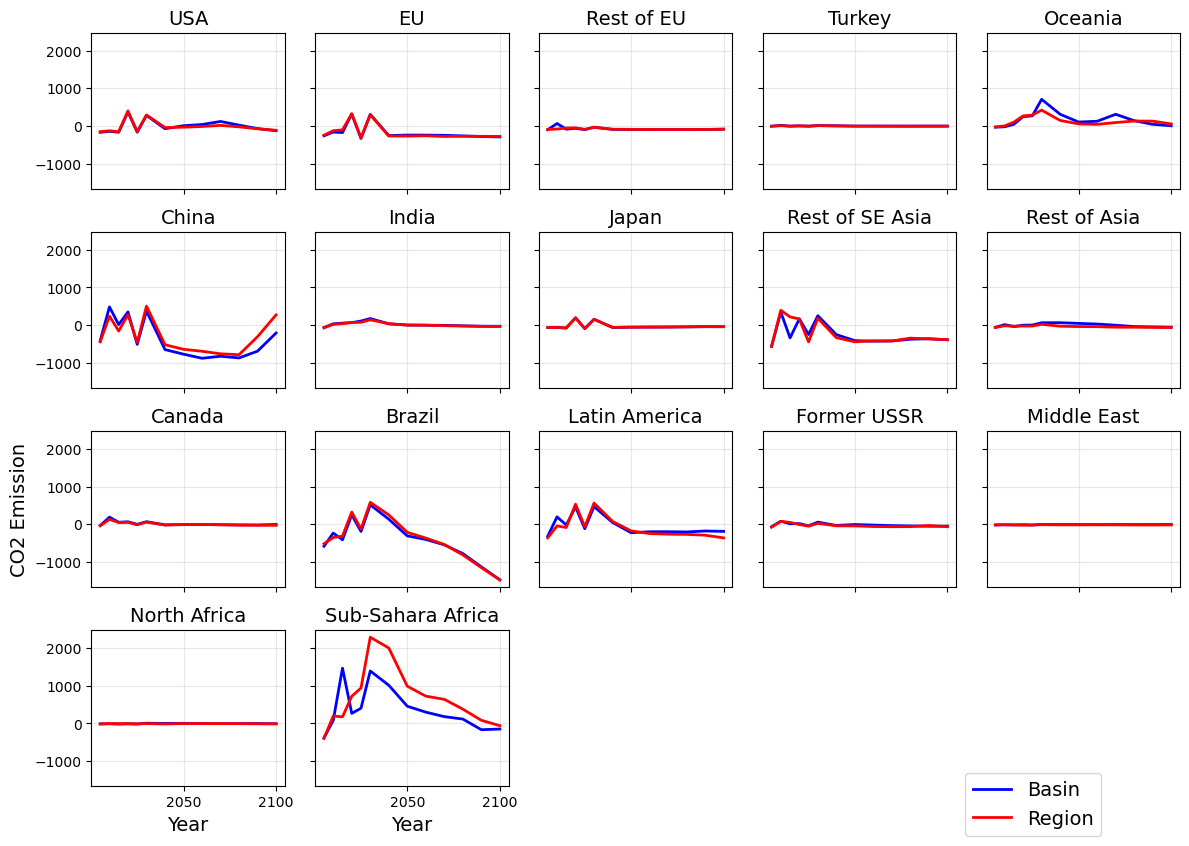

In [19]:
n = len(region_name_map)
ncols = 5
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(
        nrows, ncols,
        figsize=(12, 9),
        sharex=True,
        sharey=True
    )
axes = axes.flatten()
regions_all = list(region_name_map.values())

for i, reg in enumerate(regions_all):
    ax = axes[i]
    d = df_merged[df_merged["region"] == reg]
    # ---------- 17 regions ----------
    if reg != "World":
        
        ax.plot(d["year"], d["valueb"],  color="blue", label="Basin",linewidth=2)
        ax.plot(d["year"], d["valuer"], color="red",  label="Region",linewidth=2)

    title = region_name_map.get(reg, reg)
    ax.set_title(title, fontsize=14)

    ax.grid(alpha=0.3)        
# ---------- 行列位置 ----------
    row = i // ncols
    col = i % ncols

    # 左列只显示中间行的 y 轴标签
    mid_row = nrows // 2

    if col == 0:
        # 最左列：所有行都显示 y 轴刻度数字
        ax.tick_params(axis="y", labelleft=True)

        # 只在中间行放一次 y 轴标题
        if row == mid_row:
            ax.set_ylabel("CO2 Emission", fontsize=14)
    else:
        # 其他列：完全关闭 y 轴
        ax.tick_params(axis="y",labelleft=False)

    # 底行显示 x 轴
    if row == nrows - 1:
        ax.set_xlabel("Year", fontsize=14)
        ax.tick_params(axis="x", labelbottom=True)
    else:
        ax.tick_params(axis="x", labelbottom=False)

# ---------- legend（只放一次） ----------
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.8, 0.1),
    ncol=1,
    fontsize=14
)

# ---------- 删除多余子图 ----------
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.savefig(
    f"../../plot/Emi_CO2/Emi_CO2_compare.png",
    dpi=600,
    bbox_inches="tight"
)
plt.show()